# Neural network lab - 2A202603012

Completed custom PyTorch implementation, following Parts 0-4 of the lab.

On Colab select **Runtime > Change runtime type > T4 GPU**, then **Run all**. Approve the Drive mount.
This notebook installs its bundled code in `MyDrive/NeuralNetworkLab/submission_2A202603012/code/`.
Existing changed modules are backed up outside the submission. No GitHub push or separate module upload is needed.
The common experiment budget is 20 epochs. Saved outputs below document the original measured run.
Restart & Run All preserves submitted results and trains in a separate directory when checkpoints are absent
or the environment differs. Unfinished compatible runs can reuse completed checkpoints.

Predictions below are hypotheses written before training. Observations and the report draft are generated from measured outputs.
Review the explanations and add your own conclusions before submission. Final selection uses validation only.


In [1]:
# Change these settings before the first run, not after viewing eval scores.
STUDENT_ID = "2A202603012"
EPOCHS = 20
INSTALL_BUNDLED_CODE = True


In [2]:
import base64
import importlib.util
import io
import json
import os
from pathlib import Path
import re
import shutil
import subprocess
import sys
import time
import zipfile

if not re.fullmatch(r"[A-Za-z0-9_-]+", STUDENT_ID):
    raise ValueError("Invalid student ID.")
try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_ROOT = Path("/content/K4-Track4-Day1-Neuralnetwork")
    if not REPO_ROOT.exists():
        subprocess.run(["git", "clone", "https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git",
                        str(REPO_ROOT)], check=True)
    OUT_DIR = Path("/content/drive/MyDrive/NeuralNetworkLab") / f"submission_{STUDENT_ID}"
else:
    current = Path.cwd().resolve()
    REPO_ROOT = next((p for p in [current, *current.parents]
                      if (p / "data/covtype.csv.gz").exists() and (p / "scripts/split_data.py").exists()), None)
    if REPO_ROOT is None:
        raise RuntimeError("Run from this repository or a submission/code directory.")
    OUT_DIR = REPO_ROOT / f"submission_{STUDENT_ID}"
CODE_DIR = OUT_DIR / "code"
CODE_DIR.mkdir(parents=True, exist_ok=True)
# This bundle contains the completed local modules, not the upstream scaffold.
BUNDLE = '...'
if INSTALL_BUNDLED_CODE:
    backup_dir = OUT_DIR.parent / ".lab_backups" / OUT_DIR.name / time.strftime("%Y%m%d-%H%M%S")
    with zipfile.ZipFile(io.BytesIO(base64.b64decode(BUNDLE))) as archive:
        for name in archive.namelist():
            if Path(name).name != name:
                raise ValueError("Unsafe bundle member.")
            target, content = CODE_DIR / name, archive.read(name)
            if target.exists() and target.read_bytes() != content:
                backup_dir.mkdir(parents=True, exist_ok=True)
                shutil.copy2(target, backup_dir / name)
                print("Backed up:", target.name)
            if not target.exists() or target.read_bytes() != content:
                target.write_bytes(content)
for module, package in (("numpy", "numpy"), ("pandas", "pandas"), ("sklearn", "scikit-learn"),
                        ("matplotlib", "matplotlib"), ("openpyxl", "openpyxl"), ("torch", "torch")):
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", package], check=True)
os.chdir(CODE_DIR)
sys.path.insert(0, str(CODE_DIR))
for name in ("data", "model", "optimizer", "train", "plots", "results_table", "experiments", "report", "submission", "run_lab"):
    sys.modules.pop(name, None)
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Markdown, Image
from data import prepare_data
from train import supports_bf16
from experiments import LabRunner, health_checks, lr_trials, best_by_validation, seed_statistics, topic_trials, PREDICTIONS
from results_table import write_json
from report import observation
from submission import finalize
from run_lab import copy_code

device = "cuda" if torch.cuda.is_available() else "cpu"
if IN_COLAB and device != "cuda":
    raise RuntimeError("Select Runtime > Change runtime type > T4 GPU, then run all again.")
if device == "cpu":
    torch.set_num_threads(1)
print("PyTorch:", torch.__version__, "Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), "Native BF16 supported:", supports_bf16())
print("Persistent output:", OUT_DIR)


Mounted at /content/drive
PyTorch: 2.11.0+cu130 Device: cuda
GPU: Tesla T4 Native BF16 supported: False
Persistent output: /content/drive/MyDrive/NeuralNetworkLab/submission_2A202603012


## Part 0 - Data

Use the supplied train/eval metadata without changing it. Split 20% of the official training rows into validation,
stratified by class with seed 42. Fit mean and population standard deviation using the remaining training rows only.
Standardize columns 0-9 and preserve the 44 binary columns. Eval is reserved for Part 4.


In [3]:
processed = REPO_ROOT / "data/processed"
if not all((processed / name).exists() for name in ("train.npz", "eval.npz")):
    subprocess.run([sys.executable, str(REPO_ROOT / "scripts/split_data.py")], cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=str(processed))
assert tuple(data["X_tr"].shape) == (371847, 54)
assert tuple(data["X_val"].shape) == (92962, 54)
assert tuple(data["X_eval"].shape) == (116203, 54)
assert data["X_tr"].dtype == torch.float32 and data["y_tr"].dtype == torch.int64
numeric = data["X_tr"][:, :10].double()
assert torch.allclose(numeric.mean(0), torch.zeros(10, dtype=torch.float64, device=device), atol=1e-5)
assert torch.allclose(numeric.std(0, unbiased=False), torch.ones(10, dtype=torch.float64, device=device), atol=1e-5)
print("Train numeric means:", numeric.mean(0).cpu().numpy())
print("Train numeric standard deviations:", numeric.std(0, unbiased=False).cpu().numpy())

# Route training before diagnostics write any files, preserving submitted evidence.
runner = LabRunner(data, REPO_ROOT, OUT_DIR)
OUT_DIR = runner.out
CODE_DIR = OUT_DIR / "code"
copy_code(CODE_DIR)
os.chdir(CODE_DIR)
sys.path.insert(0, str(CODE_DIR))
print("Training output:", OUT_DIR)


tr: X=(371847, 54), y=(371847,)
val: X=(92962, 54), y=(92962,)
eval: X=(116203, 54), y=(116203,)
Validation majority-class accuracy: 0.487597
Train numeric means: [-6.73883753e-11 -1.46488192e-10 -3.42966406e-09  3.00766271e-10
 -1.53744727e-09 -1.02212679e-10 -1.56614732e-09 -1.91377376e-09
 -1.41332503e-09  6.88944764e-10]
Train numeric standard deviations: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Part 1 - Model and health checks

M-base is 54-256-128-7 with 47,879 trainable parameters. Hidden layers use ReLU; the output is raw logits.
Check shape, initial CE against ln(7), nonzero gradients in every parameter, and overfitting 20 examples.
An initial CE near ln(7) is a diagnostic expectation, not an exact assertion for randomly initialized logits.


{
  "parameters": 47879,
  "logits_shape": [
    8,
    7
  ],
  "step0_loss": 2.2690618110553,
  "ln7": 1.9459101490553132,
  "gradient_norms": {
    "net.0.weight": 0.5070549845695496,
    "net.0.bias": 0.3422401249408722,
    "net.2.weight": 2.021228551864624,
    "net.2.bias": 0.44387364387512207,
    "net.4.weight": 1.9604557752609253,
    "net.4.bias": 0.5724555253982544
  },
  "tiny_loss": 4.3928430386586115e-06,
  "tiny_acc": 1.0,
  "tiny_steps": 500,
  "train_numeric_mean": [
    -6.73883753065214e-11,
    -1.4648819203626788e-10,
    -3.4296640630151753e-09,
    3.0076627087462854e-10,
    -1.537447273732033e-09,
    -1.0221267886219567e-10,
    -1.5661473180581102e-09,
    -1.913773755991803e-09,
    -1.4133250294950382e-09,
    6.889447644143128e-10
  ],
  "train_numeric_std": [
    0.9999999996974336,
    0.9999999999841026,
    1.0000000015312058,
    0.9999999972077419,
    1.0000000010486725,
    0.999999999933925,
    1.0000000000631508,
    0.9999999983967796,
    0.9

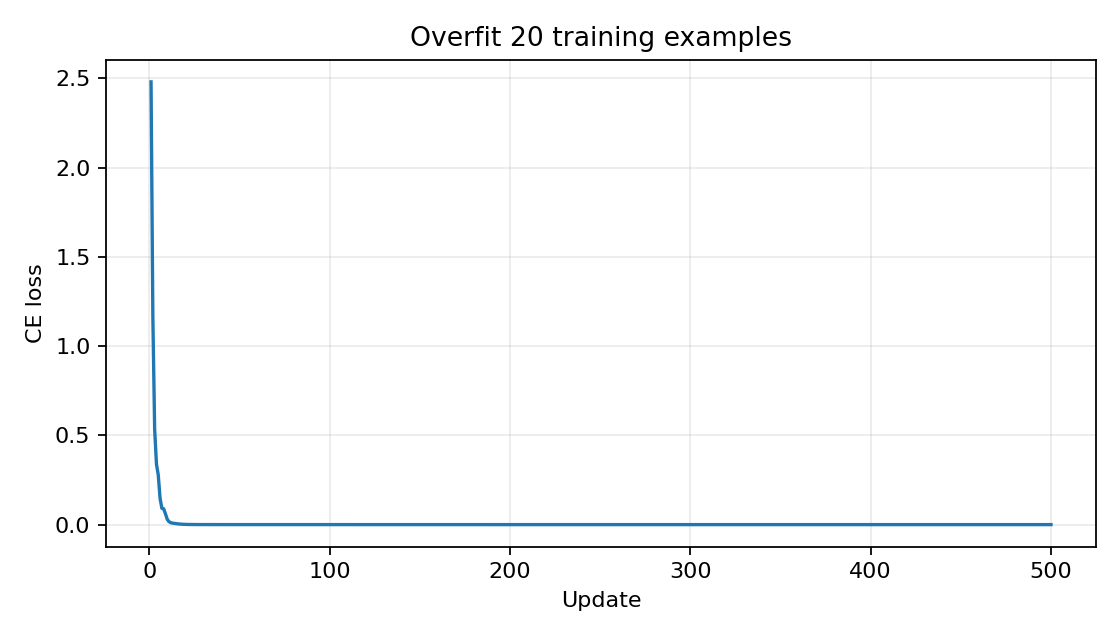

Initial CE was **2.269062**, compared with ln(7)=1.945910. The 20-example check achieved CE=0.000004 and accuracy=1.000000. Every parameter had a finite nonzero gradient. Random initial logit variance explains deviations from uniform CE.

In [4]:
diagnostics = health_checks(data, OUT_DIR)
display(Image(filename=str(OUT_DIR / "figures/diagnostic_overfit.png")))
display(Markdown(
    f"Initial CE was **{diagnostics['step0_loss']:.6f}**, compared with ln(7)={diagnostics['ln7']:.6f}. "
    f"The 20-example check achieved CE={diagnostics['tiny_loss']:.6f} and accuracy={diagnostics['tiny_acc']:.6f}. "
    "Every parameter had a finite nonzero gradient. Random initial logit variance explains deviations from uniform CE."
))


## Part 2 - Baseline and noise

**Prediction before training:** validation will identify a stable SGD+momentum learning rate. Repeat the chosen
baseline at seeds 2 and 3 to estimate training noise, keeping the split fixed.

Test rates 0.01, 0.03 and 0.1 using the full common 20-epoch budget. Every trial has a unique result and figure.
Select checkpoints by minimum validation loss, then compare validation macro-F1 at those checkpoints.
Train loss uses the same fixed 50,000-row subset in eval mode for every experiment. Full validation is evaluated in FP32.


In [5]:
baseline_trials = [runner.run(cfg) for cfg in lr_trials(EPOCHS)]
baseline = best_by_validation(baseline_trials)
print("Selected baseline rate:", baseline["cfg"]["lr"], "ID:", baseline["cfg"]["exp_id"])
baseline_seeds = [baseline]
for seed in (2, 3):
    baseline_seeds.append(runner.run({**baseline["cfg"], "seed": seed,
        "exp_id": f"base-s{seed}", "description": f"Selected baseline, seed {seed}"}))
seed_stats = seed_statistics(baseline_seeds)
write_json(OUT_DIR / "seed_statistics.json", seed_stats)
display(pd.DataFrame(seed_stats).T)


Prediction for base-lr0p01-s1: Validation should identify an SGD learning rate that converges without large oscillations. Different seeds should expose training noise.
base-lr0p01-s1 01/20: train=0.5806 val=0.5804 acc=0.7560 F1=0.4936 time=1.34s
base-lr0p01-s1 02/20: train=0.5302 val=0.5294 acc=0.7758 F1=0.5831 time=1.26s
base-lr0p01-s1 03/20: train=0.4952 val=0.4947 acc=0.7906 F1=0.5982 time=1.29s
base-lr0p01-s1 04/20: train=0.4730 val=0.4726 acc=0.8002 F1=0.6284 time=1.33s
base-lr0p01-s1 05/20: train=0.4510 val=0.4501 acc=0.8089 F1=0.6420 time=1.33s
base-lr0p01-s1 06/20: train=0.4294 val=0.4307 acc=0.8201 F1=0.6660 time=1.24s
base-lr0p01-s1 07/20: train=0.4179 val=0.4177 acc=0.8256 F1=0.6803 time=1.23s
base-lr0p01-s1 08/20: train=0.4059 val=0.4061 acc=0.8313 F1=0.6787 time=1.37s
base-lr0p01-s1 09/20: train=0.3904 val=0.3923 acc=0.8382 F1=0.6931 time=1.47s
base-lr0p01-s1 10/20: train=0.3796 val=0.3821 acc=0.8432 F1=0.7186 time=1.52s
base-lr0p01-s1 11/20: train=0.3718 val=0.3741 acc=0.

,mean,std,noise_2sigma
val_acc,0.909705,0.002442,0.004885
val_macro_f1,0.854266,0.011894,0.023788
best_val_loss,0.227110,0.005337,0.010673


Baseline train loss changed from 0.463629 to 0.218148; validation loss changed from 0.463427 to 0.236477. Best-checkpoint accuracy=0.906897; majority reference=0.487597. Baseline 2-sigma F1 reference=0.023788. Use the curves to assess convergence and overfitting; the noise reference is descriptive.

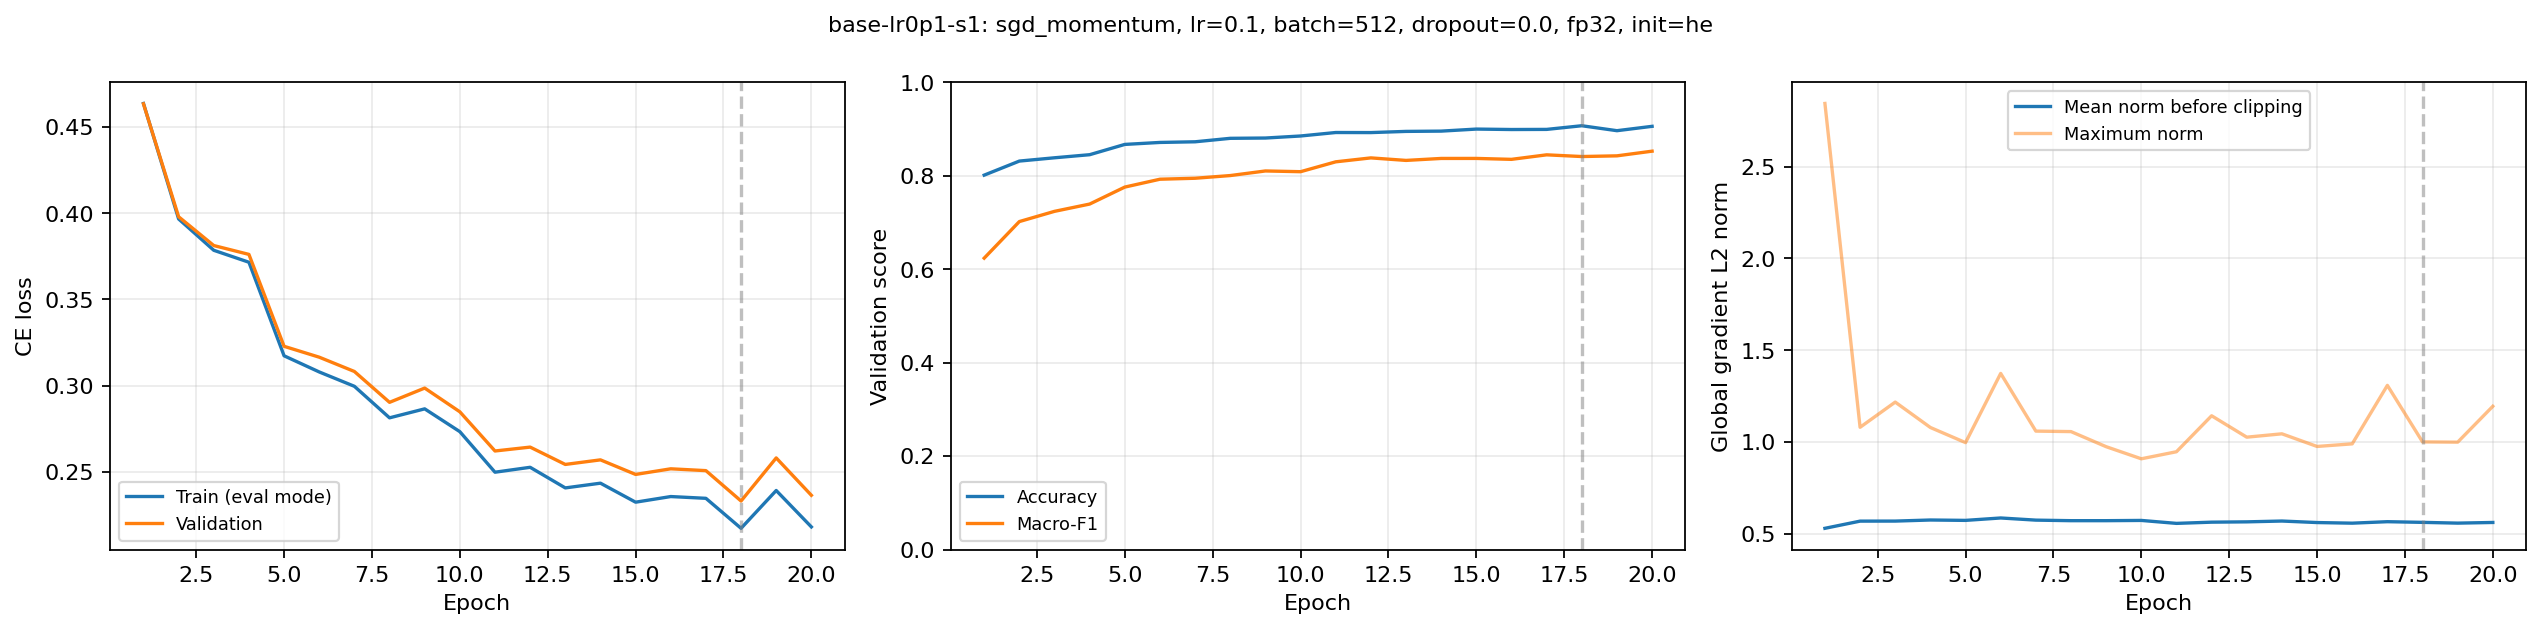

In [6]:
h = baseline["history"]
display(Markdown(
    f"Baseline train loss changed from {h['train_loss'][0]:.6f} to {h['train_loss'][-1]:.6f}; "
    f"validation loss changed from {h['val_loss'][0]:.6f} to {h['val_loss'][-1]:.6f}. "
    f"Best-checkpoint accuracy={baseline['summary']['val_acc']:.6f}; majority reference={data['majority_val_acc']:.6f}. "
    f"Baseline 2-sigma F1 reference={seed_stats['val_macro_f1']['noise_2sigma']:.6f}. "
    "Use the curves to assess convergence and overfitting; the noise reference is descriptive."
))
display(Image(filename=str(OUT_DIR / "figures" / f"{baseline['cfg']['exp_id']}.png")))


## Part 3 - Controlled experiments

**Predictions before running:**

- MSE changes gradient geometry and loss scale; compare scores rather than CE/MSE loss magnitudes.
- Adam may converge faster when each optimizer is tuned separately (Adam rates 0.0003 and 0.001).
- Batch 128 has about four times as many updates per epoch, potentially improving F1 at a higher time cost.
- Dropout 0.3 may reduce overfitting, but may hurt a model still underfitting.
- Clipping should limit spikes; a threshold derived from baseline norms and a matched 10x-rate pair test stability.
- FP16 may preserve F1 while changing speed and memory; gains must be measured. BF16 is skipped if unsupported.
- Xavier changes activation scale. Zero initialization blocks hidden ReLU gradients and should perform poorly.

All trials inherit the selected baseline and seed 1. Adam changes optimizer and learning rate deliberately for fair tuning.
`highlr-clip` is compared with `highlr-no-clip`, which differs only in clipping. Clipping does not guarantee recovery.


### opt-adam-lr0.0003

Prediction: Adam may converge faster, but the comparison must use a validation-tuned rate for each optimizer.

Prediction for opt-adam-lr0.0003: Adam may converge faster, but the comparison must use a validation-tuned rate for each optimizer.
opt-adam-lr0.0003 01/20: train=0.5682 val=0.5673 acc=0.7608 F1=0.5244 time=1.52s
opt-adam-lr0.0003 02/20: train=0.5144 val=0.5140 acc=0.7820 F1=0.6071 time=1.35s
opt-adam-lr0.0003 03/20: train=0.4769 val=0.4772 acc=0.7976 F1=0.6298 time=1.37s
opt-adam-lr0.0003 04/20: train=0.4508 val=0.4524 acc=0.8086 F1=0.6720 time=1.38s
opt-adam-lr0.0003 05/20: train=0.4316 val=0.4329 acc=0.8191 F1=0.6713 time=1.37s
opt-adam-lr0.0003 06/20: train=0.4113 val=0.4150 acc=0.8278 F1=0.6991 time=1.38s
opt-adam-lr0.0003 07/20: train=0.4005 val=0.4032 acc=0.8326 F1=0.7084 time=1.38s
opt-adam-lr0.0003 08/20: train=0.3847 val=0.3894 acc=0.8385 F1=0.7263 time=1.56s
opt-adam-lr0.0003 09/20: train=0.3738 val=0.3786 acc=0.8434 F1=0.7292 time=1.65s
opt-adam-lr0.0003 10/20: train=0.3641 val=0.3695 acc=0.8490 F1=0.7476 time=1.66s
opt-adam-lr0.0003 11/20: train=0.3584 val=0.3642 acc=0.849

Observation: Best-checkpoint F1=0.787445, accuracy=0.872787, best epoch=20; F1 difference versus base-lr0p1-s1=-0.053544. Absolute difference exceeds the baseline 2-sigma reference (0.023788). Adam scales coordinate updates using moving averages of gradients and squared gradients. AdamW decouples weight decay; neither is automatically better.

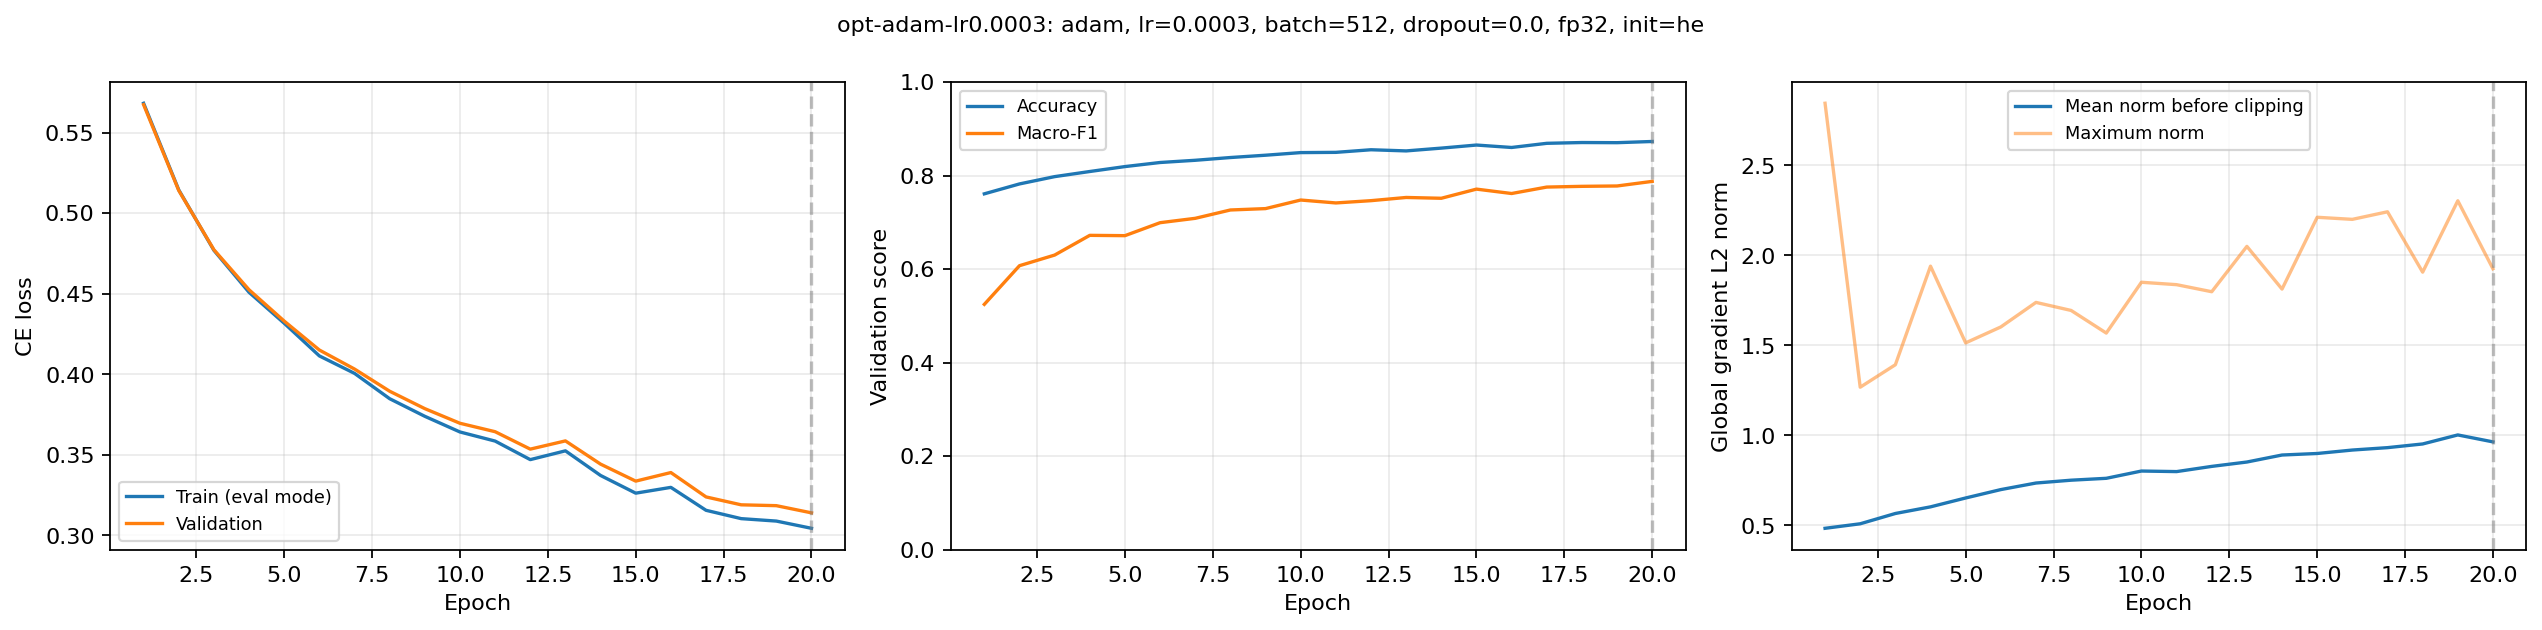

### opt-adam-lr0.001

Prediction: Adam may converge faster, but the comparison must use a validation-tuned rate for each optimizer.

Prediction for opt-adam-lr0.001: Adam may converge faster, but the comparison must use a validation-tuned rate for each optimizer.
opt-adam-lr0.001 01/20: train=0.4961 val=0.4949 acc=0.7884 F1=0.5963 time=1.39s
opt-adam-lr0.001 02/20: train=0.4201 val=0.4219 acc=0.8206 F1=0.6877 time=1.39s
opt-adam-lr0.001 03/20: train=0.3924 val=0.3956 acc=0.8340 F1=0.7194 time=1.41s
opt-adam-lr0.001 04/20: train=0.3529 val=0.3570 acc=0.8524 F1=0.7483 time=1.39s
opt-adam-lr0.001 05/20: train=0.3341 val=0.3411 acc=0.8590 F1=0.7634 time=1.36s
opt-adam-lr0.001 06/20: train=0.3158 val=0.3236 acc=0.8684 F1=0.7900 time=1.46s
opt-adam-lr0.001 07/20: train=0.3066 val=0.3138 acc=0.8713 F1=0.7980 time=1.59s
opt-adam-lr0.001 08/20: train=0.2974 val=0.3053 acc=0.8753 F1=0.7885 time=1.69s
opt-adam-lr0.001 09/20: train=0.2798 val=0.2896 acc=0.8830 F1=0.8079 time=1.38s
opt-adam-lr0.001 10/20: train=0.2756 val=0.2872 acc=0.8844 F1=0.8140 time=1.37s
opt-adam-lr0.001 11/20: train=0.2687 val=0.2793 acc=0.8868 F1=0.8262 

Observation: Best-checkpoint F1=0.847647, accuracy=0.901358, best epoch=20; F1 difference versus base-lr0p1-s1=+0.006657. Absolute difference does not exceed the baseline 2-sigma reference (0.023788). Adam scales coordinate updates using moving averages of gradients and squared gradients. AdamW decouples weight decay; neither is automatically better.

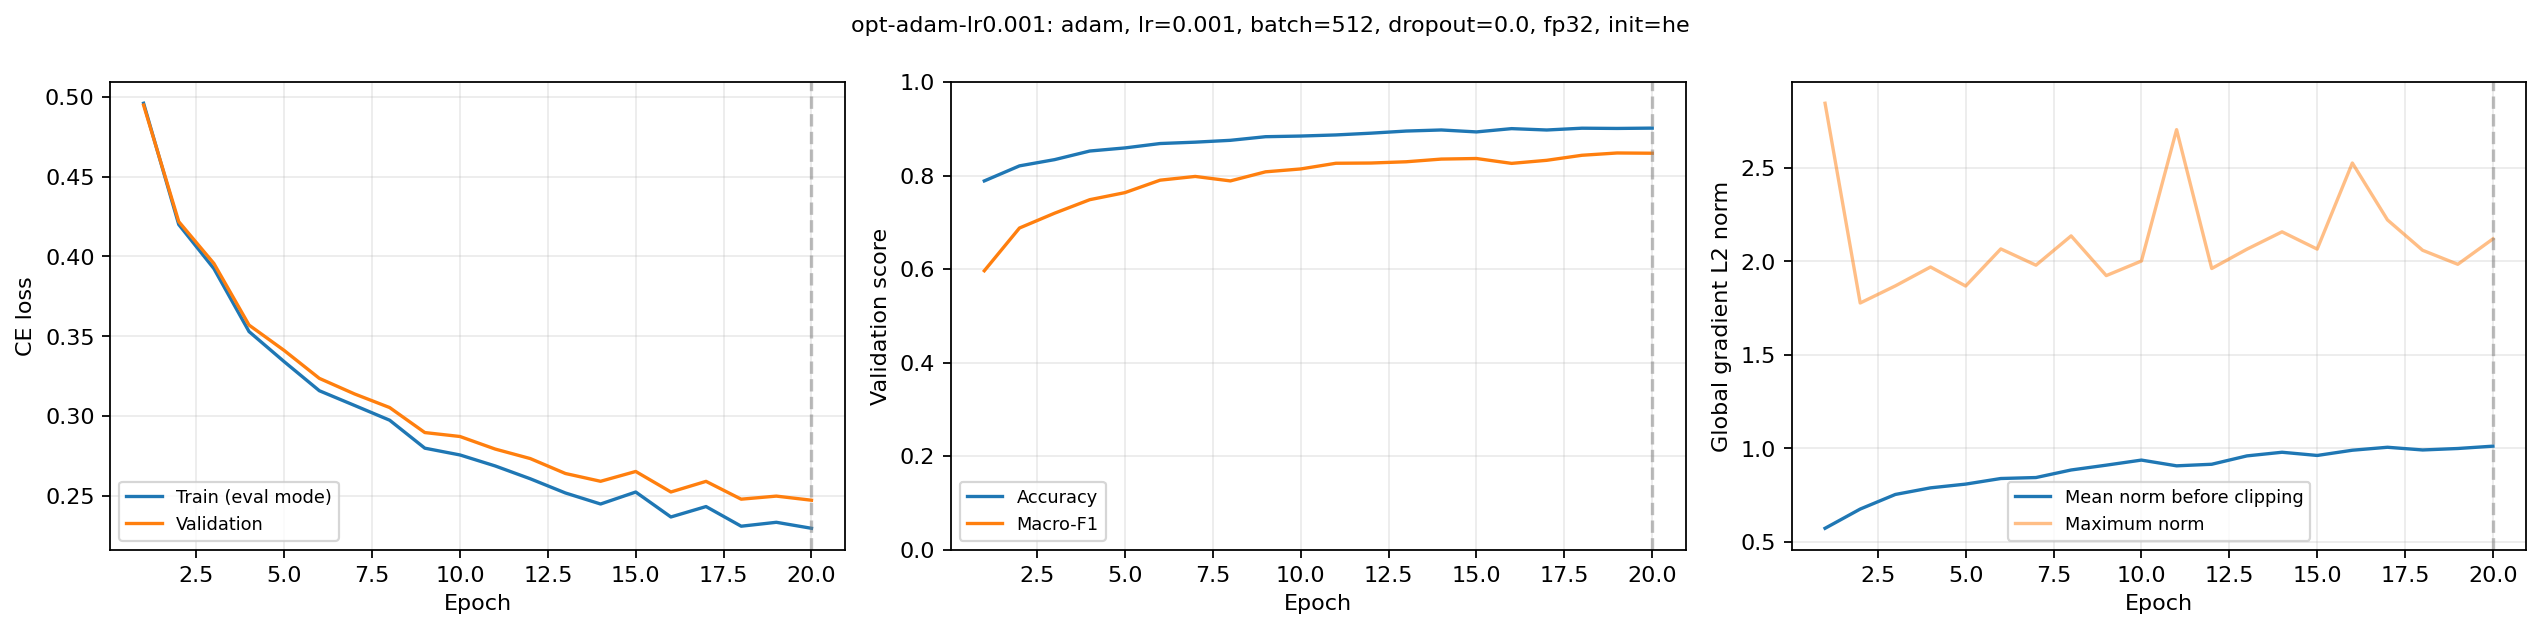

### loss-mse

Prediction: Raw-logit MSE may converge differently from CE. Its loss scale is different, so compare accuracy and macro-F1.

Prediction for loss-mse: Raw-logit MSE may converge differently from CE. Its loss scale is different, so compare accuracy and macro-F1.
loss-mse 01/20: train=0.0487 val=0.0485 acc=0.7642 F1=0.4526 time=1.31s
loss-mse 02/20: train=0.0446 val=0.0445 acc=0.7886 F1=0.5172 time=1.30s
loss-mse 03/20: train=0.0419 val=0.0419 acc=0.8009 F1=0.5279 time=1.27s
loss-mse 04/20: train=0.0402 val=0.0403 acc=0.8133 F1=0.5782 time=1.29s
loss-mse 05/20: train=0.0385 val=0.0386 acc=0.8188 F1=0.6170 time=1.46s
loss-mse 06/20: train=0.0369 val=0.0372 acc=0.8280 F1=0.6335 time=1.47s
loss-mse 07/20: train=0.0357 val=0.0360 acc=0.8349 F1=0.6553 time=1.53s
loss-mse 08/20: train=0.0347 val=0.0351 acc=0.8407 F1=0.6768 time=1.27s
loss-mse 09/20: train=0.0341 val=0.0344 acc=0.8446 F1=0.6664 time=1.32s
loss-mse 10/20: train=0.0334 val=0.0336 acc=0.8492 F1=0.6939 time=1.39s
loss-mse 11/20: train=0.0330 val=0.0333 acc=0.8515 F1=0.6930 time=1.35s
loss-mse 12/20: train=0.0328 val=0.0332 acc=0.8493 F1=0.6979 time=1.38s


Observation: Best-checkpoint F1=0.725932, accuracy=0.869893, best epoch=20; F1 difference versus base-lr0p1-s1=-0.115057. Absolute difference exceeds the baseline 2-sigma reference (0.023788). CE applies log-softmax to raw logits. MSE regresses seven raw logits toward one-hot targets and averages over all seven coordinates.

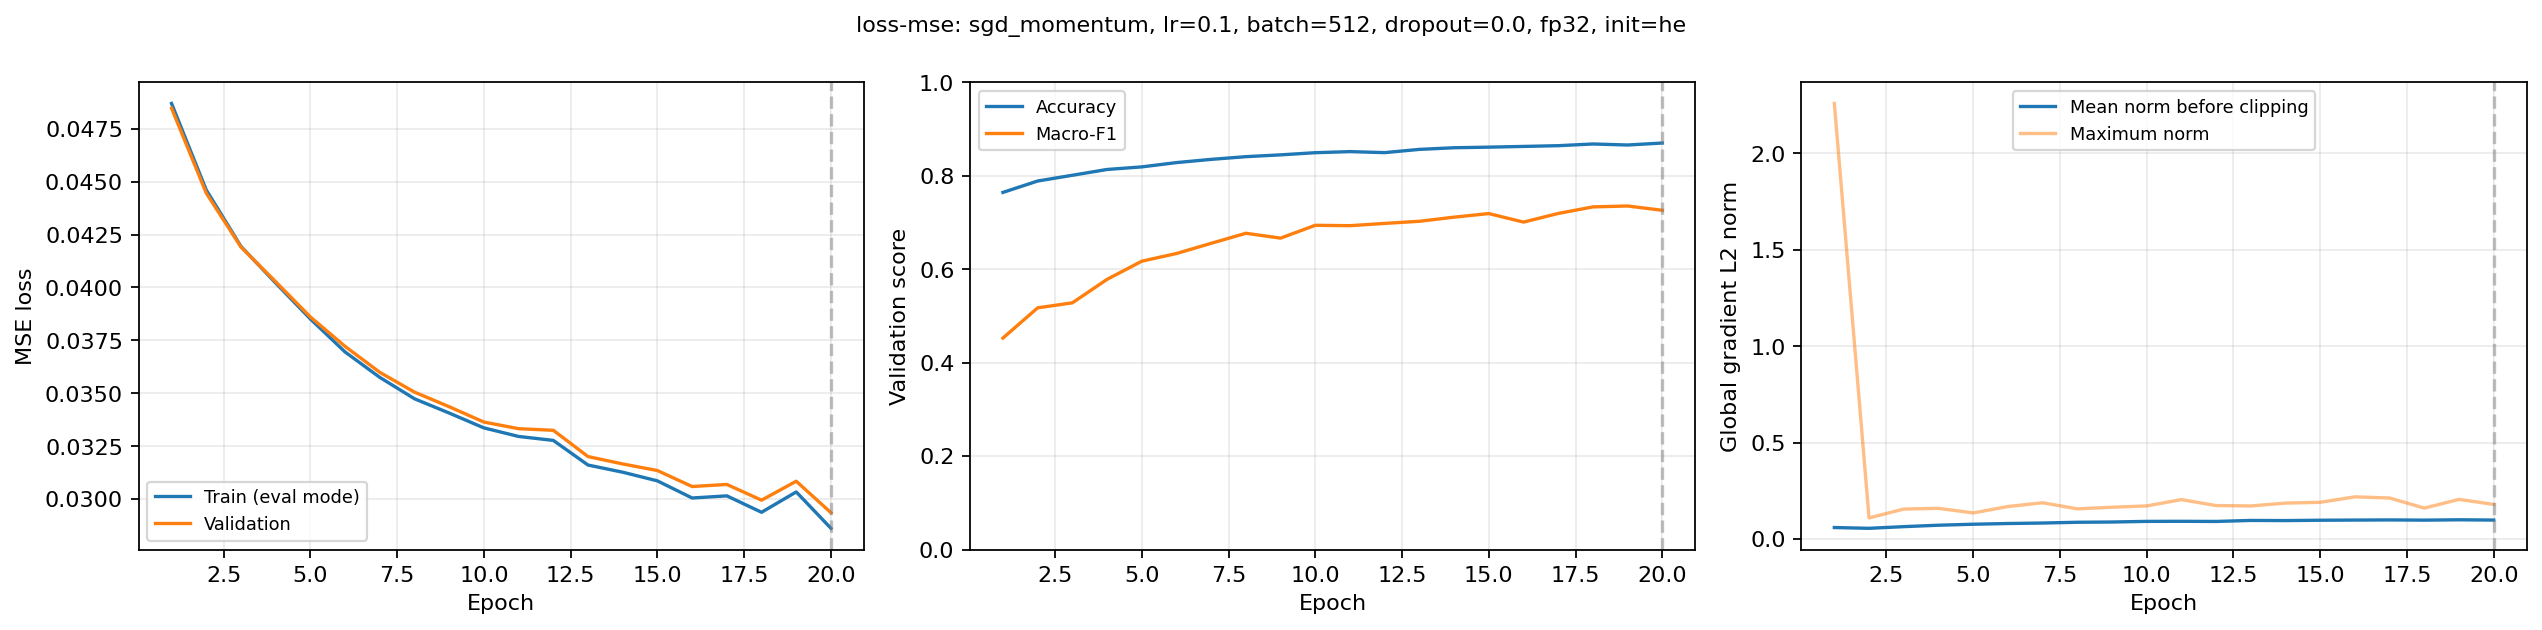

### batch-128

Prediction: A smaller batch increases updates per epoch and gradient noise; it may improve F1 at a higher time cost.

Prediction for batch-128: A smaller batch increases updates per epoch and gradient noise; it may improve F1 at a higher time cost.
batch-128 01/20: train=0.4299 val=0.4280 acc=0.8184 F1=0.6594 time=4.91s
batch-128 02/20: train=0.3685 val=0.3745 acc=0.8432 F1=0.7208 time=5.49s
batch-128 03/20: train=0.3438 val=0.3474 acc=0.8568 F1=0.7725 time=4.80s
batch-128 04/20: train=0.3132 val=0.3251 acc=0.8679 F1=0.7942 time=5.16s
batch-128 05/20: train=0.2826 val=0.2907 acc=0.8816 F1=0.8002 time=5.17s
batch-128 06/20: train=0.2786 val=0.2884 acc=0.8824 F1=0.8070 time=5.18s
batch-128 07/20: train=0.2671 val=0.2813 acc=0.8874 F1=0.8063 time=5.54s
batch-128 08/20: train=0.2572 val=0.2749 acc=0.8902 F1=0.8193 time=4.86s
batch-128 09/20: train=0.2606 val=0.2754 acc=0.8883 F1=0.8185 time=4.92s
batch-128 10/20: train=0.2478 val=0.2633 acc=0.8951 F1=0.8240 time=5.42s
batch-128 11/20: train=0.2464 val=0.2612 acc=0.8956 F1=0.8309 time=4.86s
batch-128 12/20: train=0.2334 val=0.2486 acc=0.9000 F1=0.8256 time

Observation: Best-checkpoint F1=0.860720, accuracy=0.911846, best epoch=20; F1 difference versus base-lr0p1-s1=+0.019731. Absolute difference does not exceed the baseline 2-sigma reference (0.023788). Batch=128; time per epoch=5.149s. At fixed epochs, batch 128 produces about four times as many updates as batch 512. Time and update count therefore change with batch size.

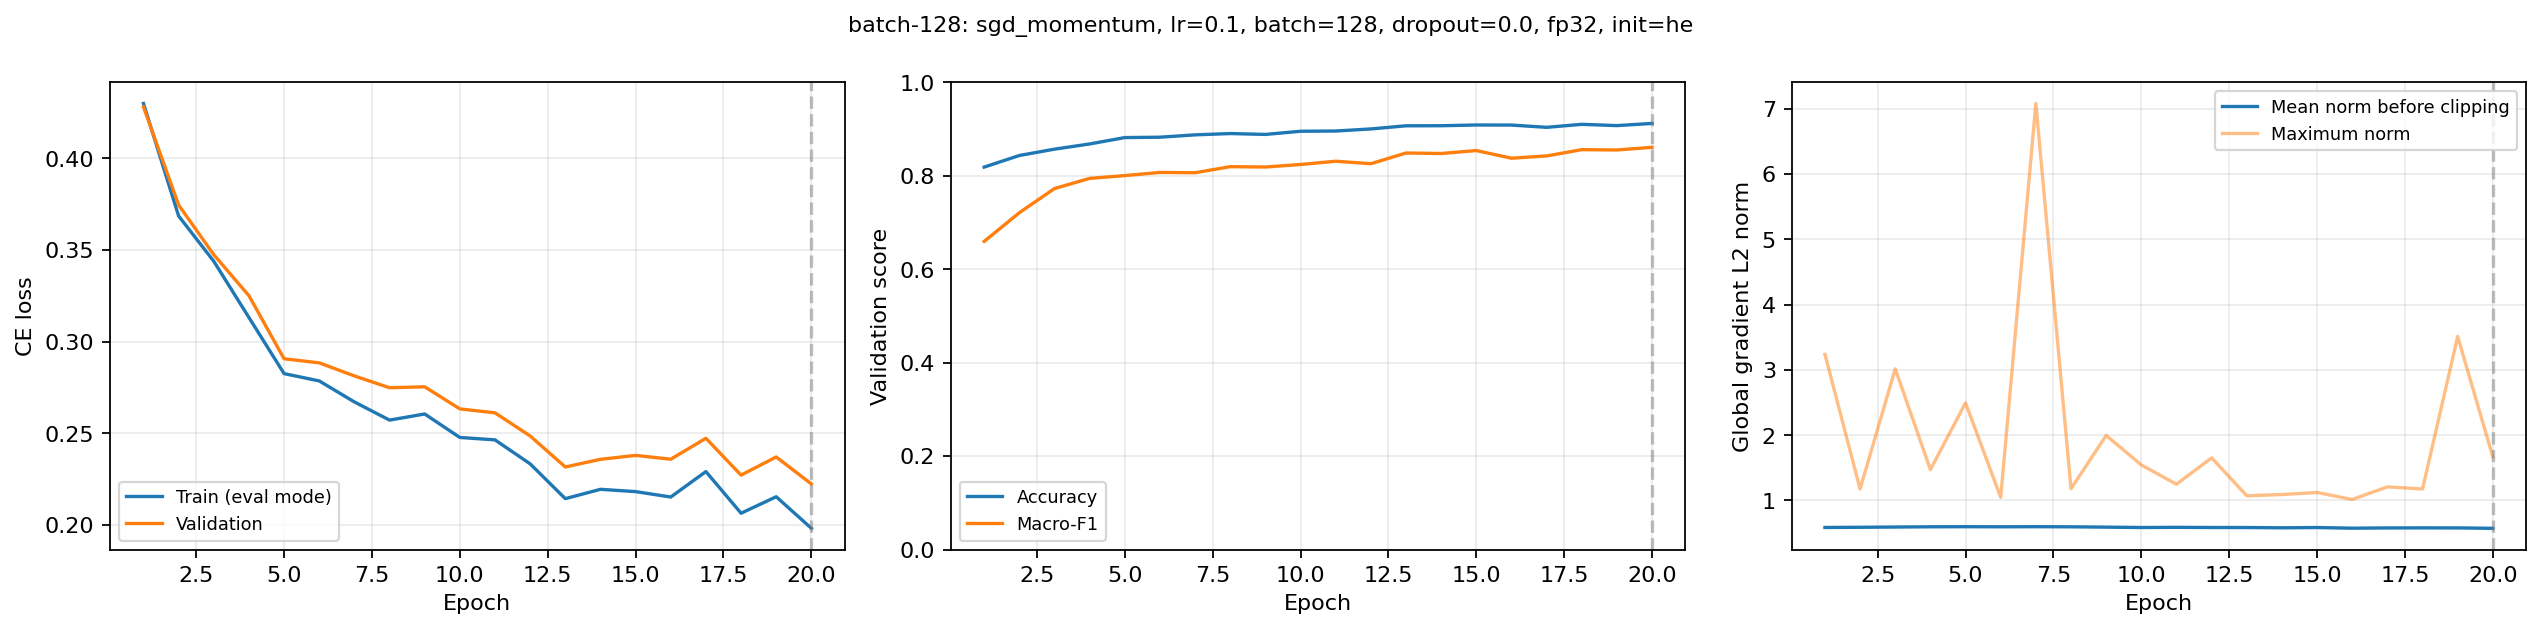

### dropout-0p3

Prediction: Dropout 0.3 should reduce a genuine generalization gap; it may hurt if the baseline is still underfitting.

Prediction for dropout-0p3: Dropout 0.3 should reduce a genuine generalization gap; it may hurt if the baseline is still underfitting.
dropout-0p3 01/20: train=0.5420 val=0.5392 acc=0.7627 F1=0.5391 time=1.55s
dropout-0p3 02/20: train=0.4822 val=0.4803 acc=0.7963 F1=0.6246 time=1.45s
dropout-0p3 03/20: train=0.4471 val=0.4473 acc=0.8107 F1=0.6496 time=1.48s
dropout-0p3 04/20: train=0.4249 val=0.4249 acc=0.8215 F1=0.6613 time=1.42s
dropout-0p3 05/20: train=0.4040 val=0.4043 acc=0.8316 F1=0.6650 time=1.46s
dropout-0p3 06/20: train=0.3946 val=0.3942 acc=0.8357 F1=0.7048 time=1.38s
dropout-0p3 07/20: train=0.3826 val=0.3825 acc=0.8428 F1=0.7238 time=1.36s
dropout-0p3 08/20: train=0.3763 val=0.3770 acc=0.8395 F1=0.7207 time=1.54s
dropout-0p3 09/20: train=0.3701 val=0.3699 acc=0.8487 F1=0.7310 time=1.58s
dropout-0p3 10/20: train=0.3605 val=0.3614 acc=0.8489 F1=0.7395 time=1.67s
dropout-0p3 11/20: train=0.3511 val=0.3521 acc=0.8507 F1=0.7350 time=1.30s
dropout-0p3 12/20: train=0.3490 val=0.35

Observation: Best-checkpoint F1=0.785274, accuracy=0.871550, best epoch=20; F1 difference versus base-lr0p1-s1=-0.055715. Absolute difference exceeds the baseline 2-sigma reference (0.023788). Final loss gap=0.003498 versus reference gap=0.018329. Randomly masking hidden activations regularizes co-adaptation. Train loss is measured with dropout disabled to make the gap interpretable.

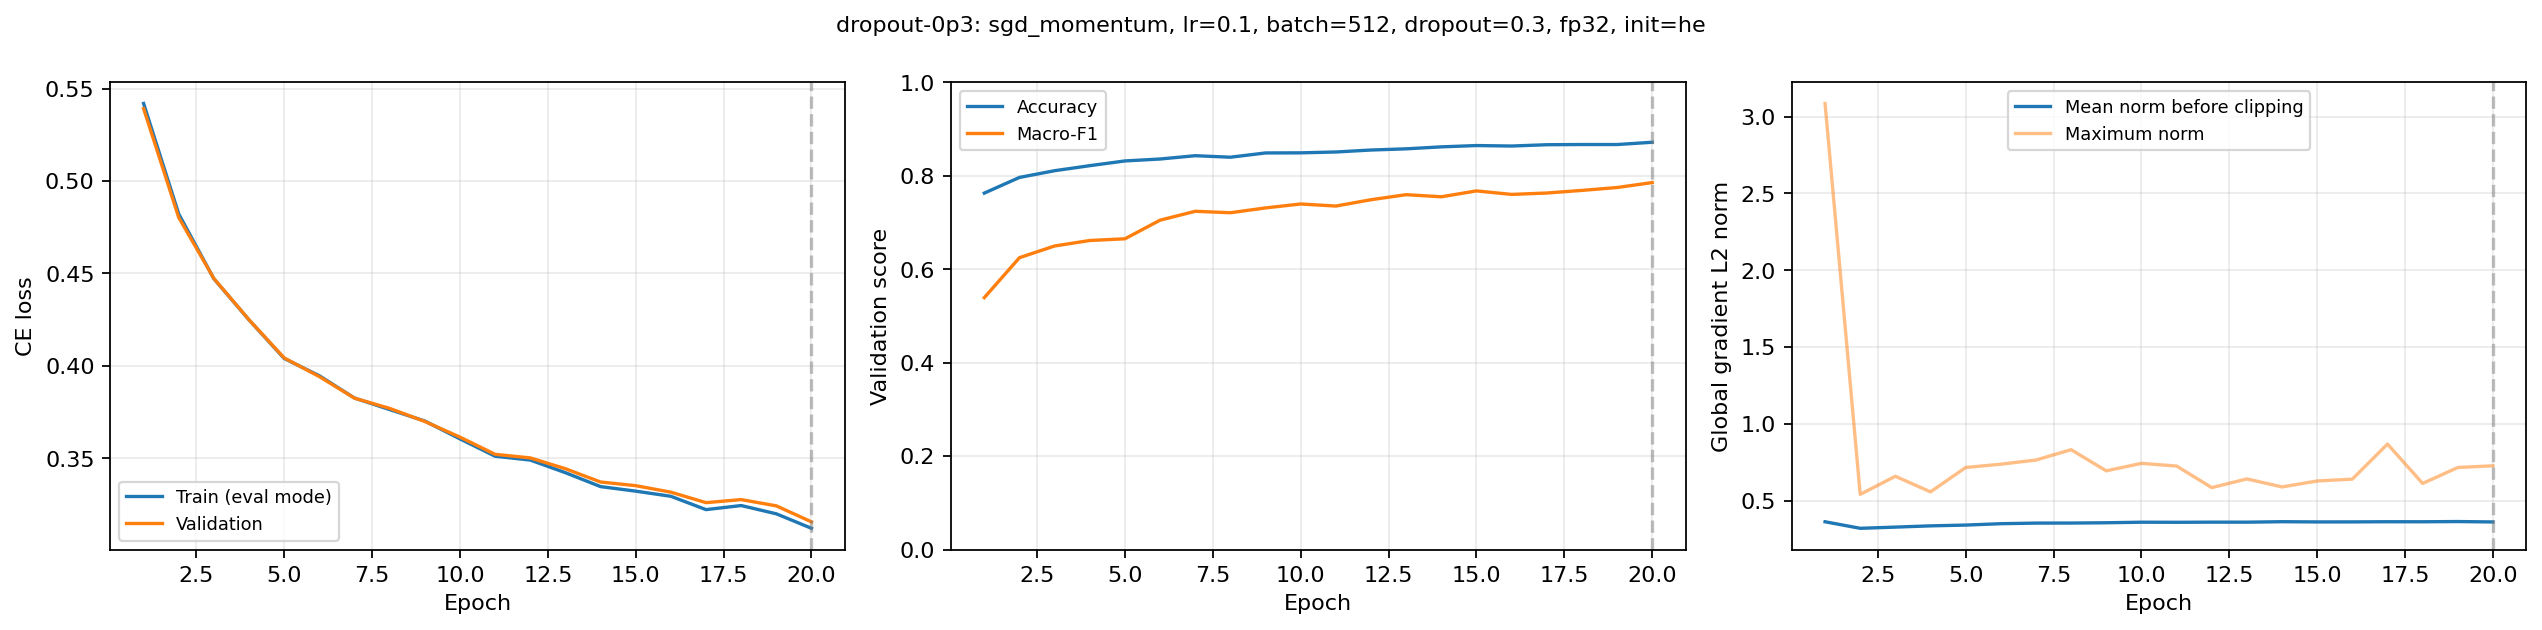

### clip-normal

Prediction: Clipping should cap large updates. A matched high-rate pair tests whether it improves stability; recovery is not guaranteed.

Prediction for clip-normal: Clipping should cap large updates. A matched high-rate pair tests whether it improves stability; recovery is not guaranteed.
clip-normal 01/20: train=0.4746 val=0.4744 acc=0.7979 F1=0.6153 time=1.25s
clip-normal 02/20: train=0.3994 val=0.4006 acc=0.8311 F1=0.7069 time=1.24s
clip-normal 03/20: train=0.3776 val=0.3830 acc=0.8389 F1=0.7265 time=1.23s
clip-normal 04/20: train=0.3715 val=0.3782 acc=0.8455 F1=0.7359 time=1.24s
clip-normal 05/20: train=0.3351 val=0.3436 acc=0.8573 F1=0.7722 time=1.24s
clip-normal 06/20: train=0.3069 val=0.3177 acc=0.8684 F1=0.7899 time=1.27s
clip-normal 07/20: train=0.2986 val=0.3096 acc=0.8726 F1=0.7944 time=1.39s
clip-normal 08/20: train=0.2953 val=0.3064 acc=0.8738 F1=0.7936 time=1.41s
clip-normal 09/20: train=0.2967 val=0.3101 acc=0.8731 F1=0.7957 time=1.51s
clip-normal 10/20: train=0.2813 val=0.2959 acc=0.8797 F1=0.8008 time=1.24s
clip-normal 11/20: train=0.2641 val=0.2776 acc=0.8859 F1=0.8150 time=1.26s
clip-normal 12/20: tra

Observation: Best-checkpoint F1=0.841155, accuracy=0.901089, best epoch=20; F1 difference versus base-lr0p1-s1=+0.000166. Absolute difference does not exceed the baseline 2-sigma reference (0.023788). Mean epoch clipping fraction=0.9898. Global norm clipping rescales gradients by min(1, threshold/norm), limiting sudden update magnitudes without fixing bad labels or an unsuitable rate.

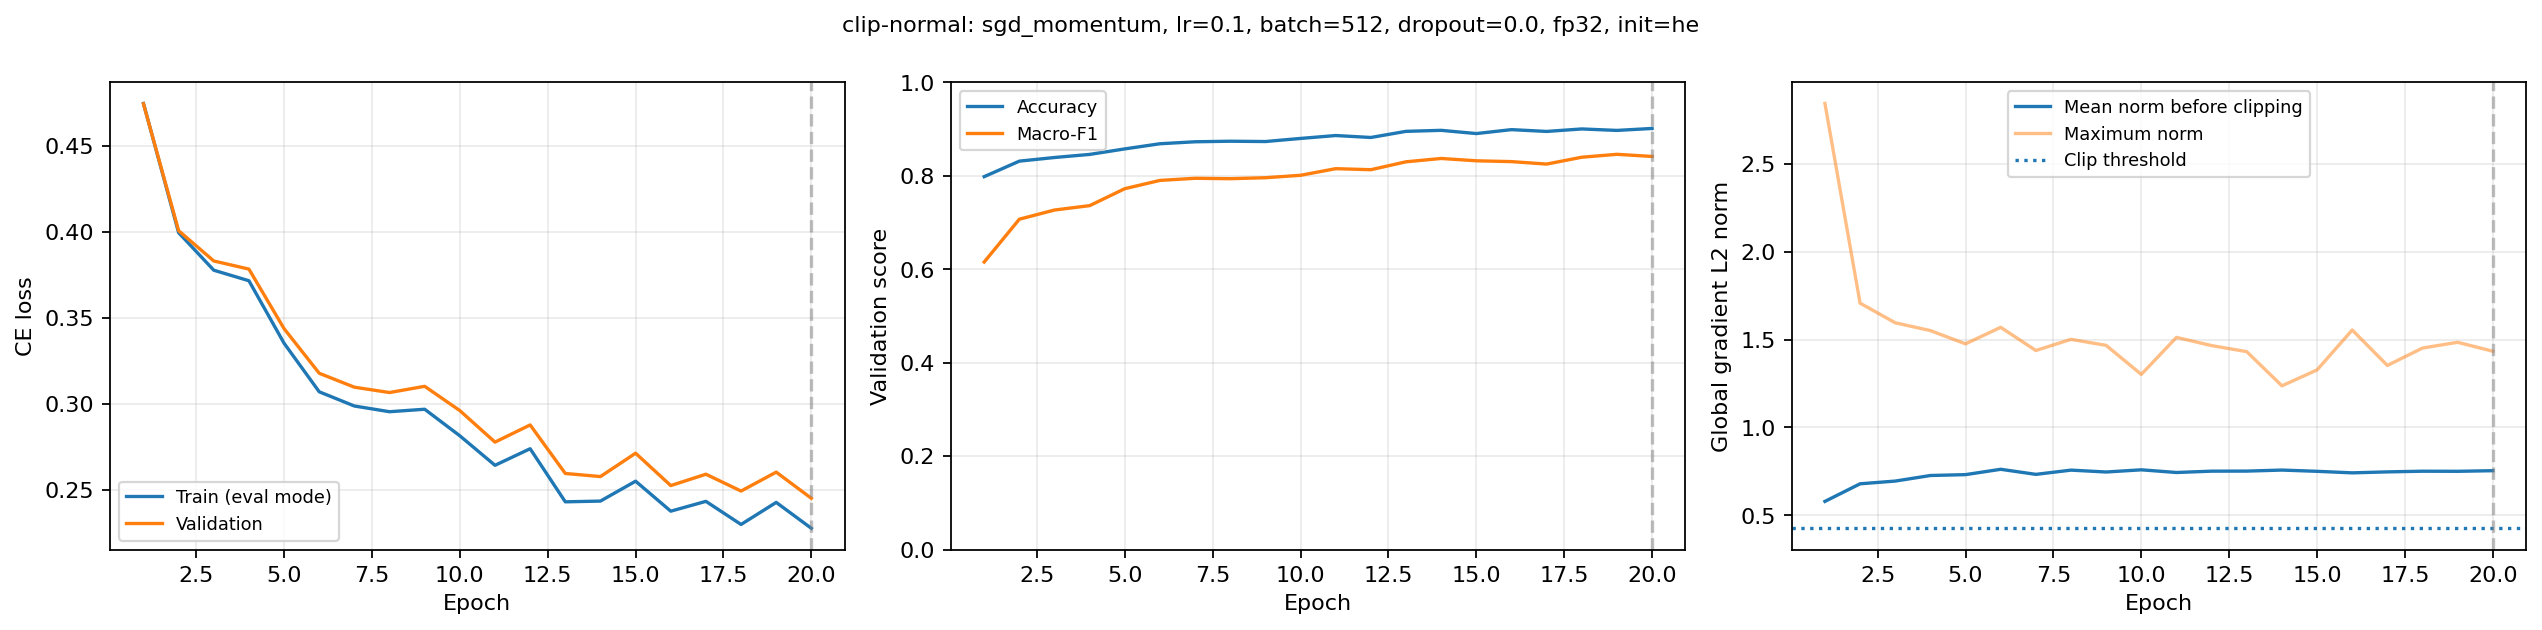

### highlr-no-clip

Prediction: Clipping should cap large updates. A matched high-rate pair tests whether it improves stability; recovery is not guaranteed.

Prediction for highlr-no-clip: Clipping should cap large updates. A matched high-rate pair tests whether it improves stability; recovery is not guaranteed.
highlr-no-clip 01/20: train=0.5425 val=0.5438 acc=0.7797 F1=0.4775 time=1.30s
highlr-no-clip 02/20: train=0.4845 val=0.4895 acc=0.7992 F1=0.6262 time=1.38s
highlr-no-clip 03/20: train=0.4532 val=0.4504 acc=0.8150 F1=0.6641 time=1.38s
highlr-no-clip 04/20: train=0.4142 val=0.4206 acc=0.8244 F1=0.7113 time=1.30s
highlr-no-clip 05/20: train=0.4366 val=0.4434 acc=0.8169 F1=0.6806 time=1.30s
highlr-no-clip 06/20: train=0.4305 val=0.4335 acc=0.8230 F1=0.7199 time=1.24s
highlr-no-clip 07/20: train=0.3829 val=0.3899 acc=0.8473 F1=0.7063 time=1.37s
highlr-no-clip 08/20: train=0.3727 val=0.3880 acc=0.8449 F1=0.7318 time=1.38s
highlr-no-clip 09/20: train=0.3873 val=0.3965 acc=0.8468 F1=0.6474 time=1.50s
highlr-no-clip 10/20: train=0.3869 val=0.3962 acc=0.8445 F1=0.7401 time=1.25s
highlr-no-clip 11/20: train=0.4066 val=0.4120 acc=0.8448 F1=0.67

Observation: Best-checkpoint F1=0.780358, accuracy=0.869506, best epoch=19; F1 difference versus base-lr0p1-s1=-0.060631. Absolute difference exceeds the baseline 2-sigma reference (0.023788). Mean epoch clipping fraction=0.0000. Global norm clipping rescales gradients by min(1, threshold/norm), limiting sudden update magnitudes without fixing bad labels or an unsuitable rate.

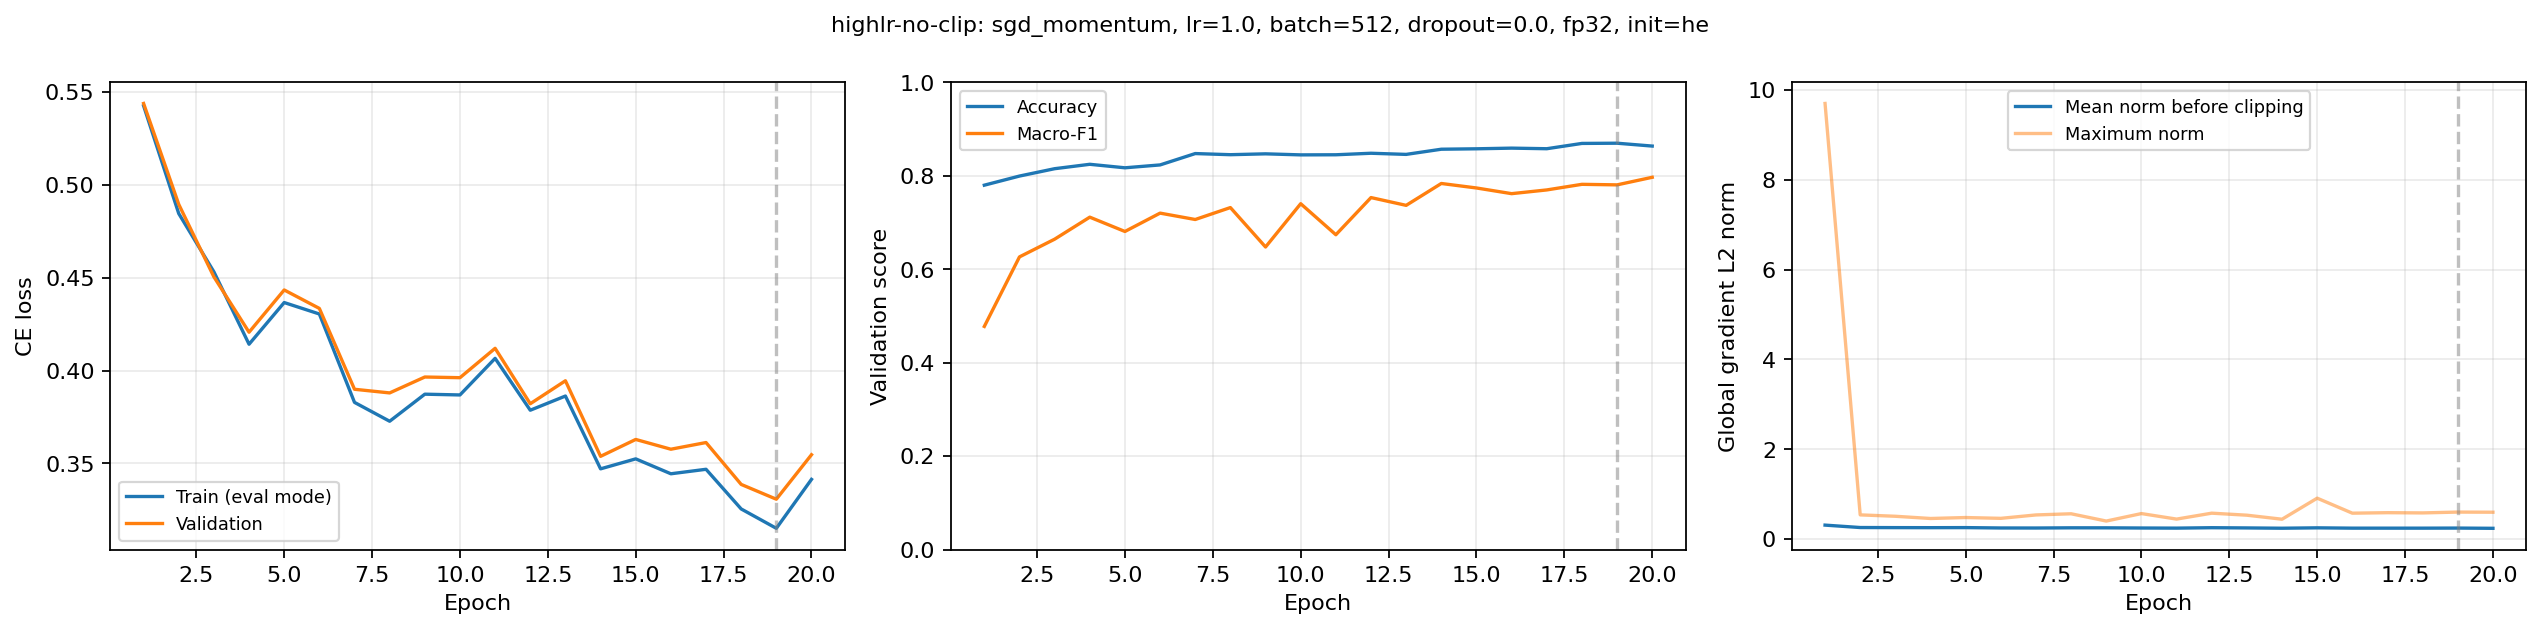

### highlr-clip

Prediction: Clipping should cap large updates. A matched high-rate pair tests whether it improves stability; recovery is not guaranteed.

Prediction for highlr-clip: Clipping should cap large updates. A matched high-rate pair tests whether it improves stability; recovery is not guaranteed.
highlr-clip 01/20: train=0.4821 val=0.4809 acc=0.7986 F1=0.5328 time=1.27s
highlr-clip 02/20: train=0.4174 val=0.4206 acc=0.8263 F1=0.6933 time=1.27s
highlr-clip 03/20: train=0.4107 val=0.4165 acc=0.8267 F1=0.7154 time=1.29s
highlr-clip 04/20: train=0.3697 val=0.3749 acc=0.8471 F1=0.7356 time=1.25s
highlr-clip 05/20: train=0.3759 val=0.3815 acc=0.8549 F1=0.7373 time=1.24s
highlr-clip 06/20: train=0.3436 val=0.3507 acc=0.8565 F1=0.7737 time=1.25s
highlr-clip 07/20: train=0.3330 val=0.3436 acc=0.8614 F1=0.7673 time=1.31s
highlr-clip 08/20: train=0.3350 val=0.3437 acc=0.8650 F1=0.7693 time=1.40s
highlr-clip 09/20: train=0.3290 val=0.3373 acc=0.8694 F1=0.7478 time=1.47s
highlr-clip 10/20: train=0.3223 val=0.3373 acc=0.8679 F1=0.7855 time=1.34s
highlr-clip 11/20: train=0.3338 val=0.3451 acc=0.8682 F1=0.7869 time=1.24s
highlr-clip 12/20: tra

Observation: Best-checkpoint F1=0.817439, accuracy=0.881102, best epoch=19; F1 difference versus highlr-no-clip=+0.037081. Absolute difference exceeds the baseline 2-sigma reference (0.023788). Mean epoch clipping fraction=0.0054. Global norm clipping rescales gradients by min(1, threshold/norm), limiting sudden update magnitudes without fixing bad labels or an unsuitable rate.

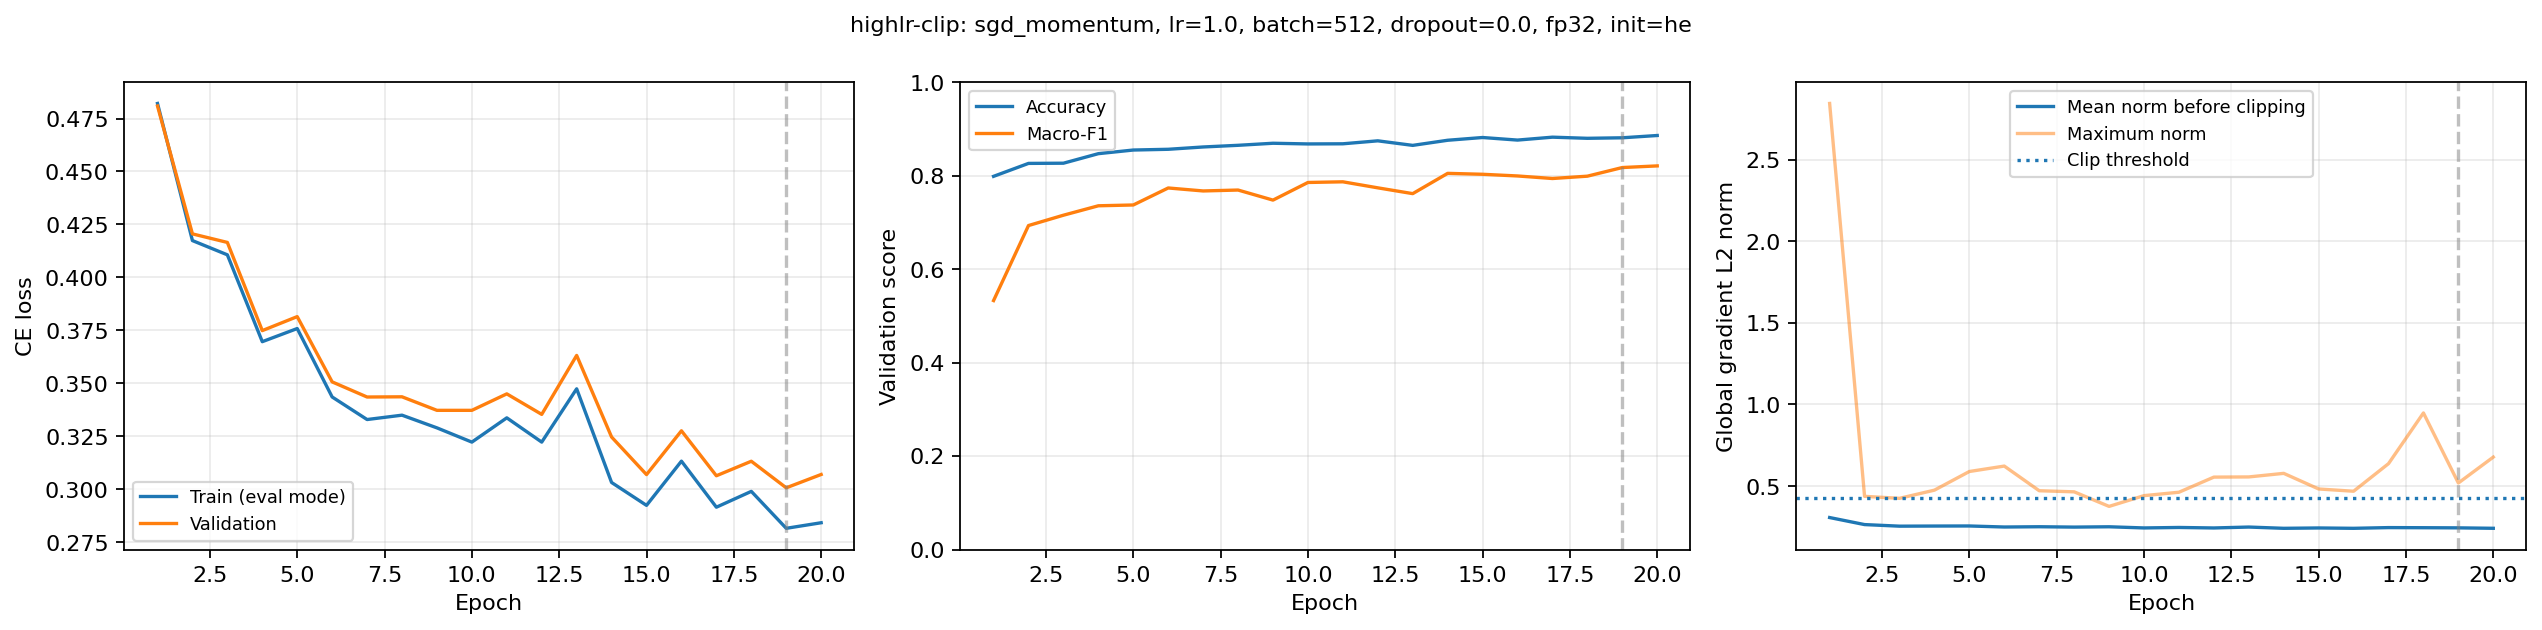

### init-xavier

Prediction: Xavier may change activation scale. Zero weights preserve symmetry and leave hidden ReLU gradients zero.

Prediction for init-xavier: Xavier may change activation scale. Zero weights preserve symmetry and leave hidden ReLU gradients zero.
init-xavier 01/20: train=0.4941 val=0.4924 acc=0.7861 F1=0.5932 time=1.25s
init-xavier 02/20: train=0.4091 val=0.4101 acc=0.8270 F1=0.6851 time=1.24s
init-xavier 03/20: train=0.4115 val=0.4112 acc=0.8277 F1=0.6962 time=1.21s
init-xavier 04/20: train=0.3978 val=0.4011 acc=0.8384 F1=0.7226 time=1.24s
init-xavier 05/20: train=0.3265 val=0.3318 acc=0.8635 F1=0.7798 time=1.24s
init-xavier 06/20: train=0.3064 val=0.3127 acc=0.8716 F1=0.7977 time=1.26s
init-xavier 07/20: train=0.3002 val=0.3083 acc=0.8726 F1=0.7881 time=1.23s
init-xavier 08/20: train=0.2848 val=0.2936 acc=0.8789 F1=0.7975 time=1.40s
init-xavier 09/20: train=0.2865 val=0.2965 acc=0.8786 F1=0.7894 time=1.38s
init-xavier 10/20: train=0.2712 val=0.2826 acc=0.8852 F1=0.8127 time=1.49s
init-xavier 11/20: train=0.2543 val=0.2616 acc=0.8945 F1=0.8335 time=1.24s
init-xavier 12/20: train=0.2580 val=0.2681

Observation: Best-checkpoint F1=0.837379, accuracy=0.902530, best epoch=17; F1 difference versus base-lr0p1-s1=-0.003611. Absolute difference does not exceed the baseline 2-sigma reference (0.023788). Initial activation standard deviations=[0.2780497372150421, 0.2202722579240799, 0.196858748793602]. He uses variance 2/fan_in for ReLU; Xavier uses 2/(fan_in+fan_out). At zero initialization, ReLU derivatives block hidden-layer learning.

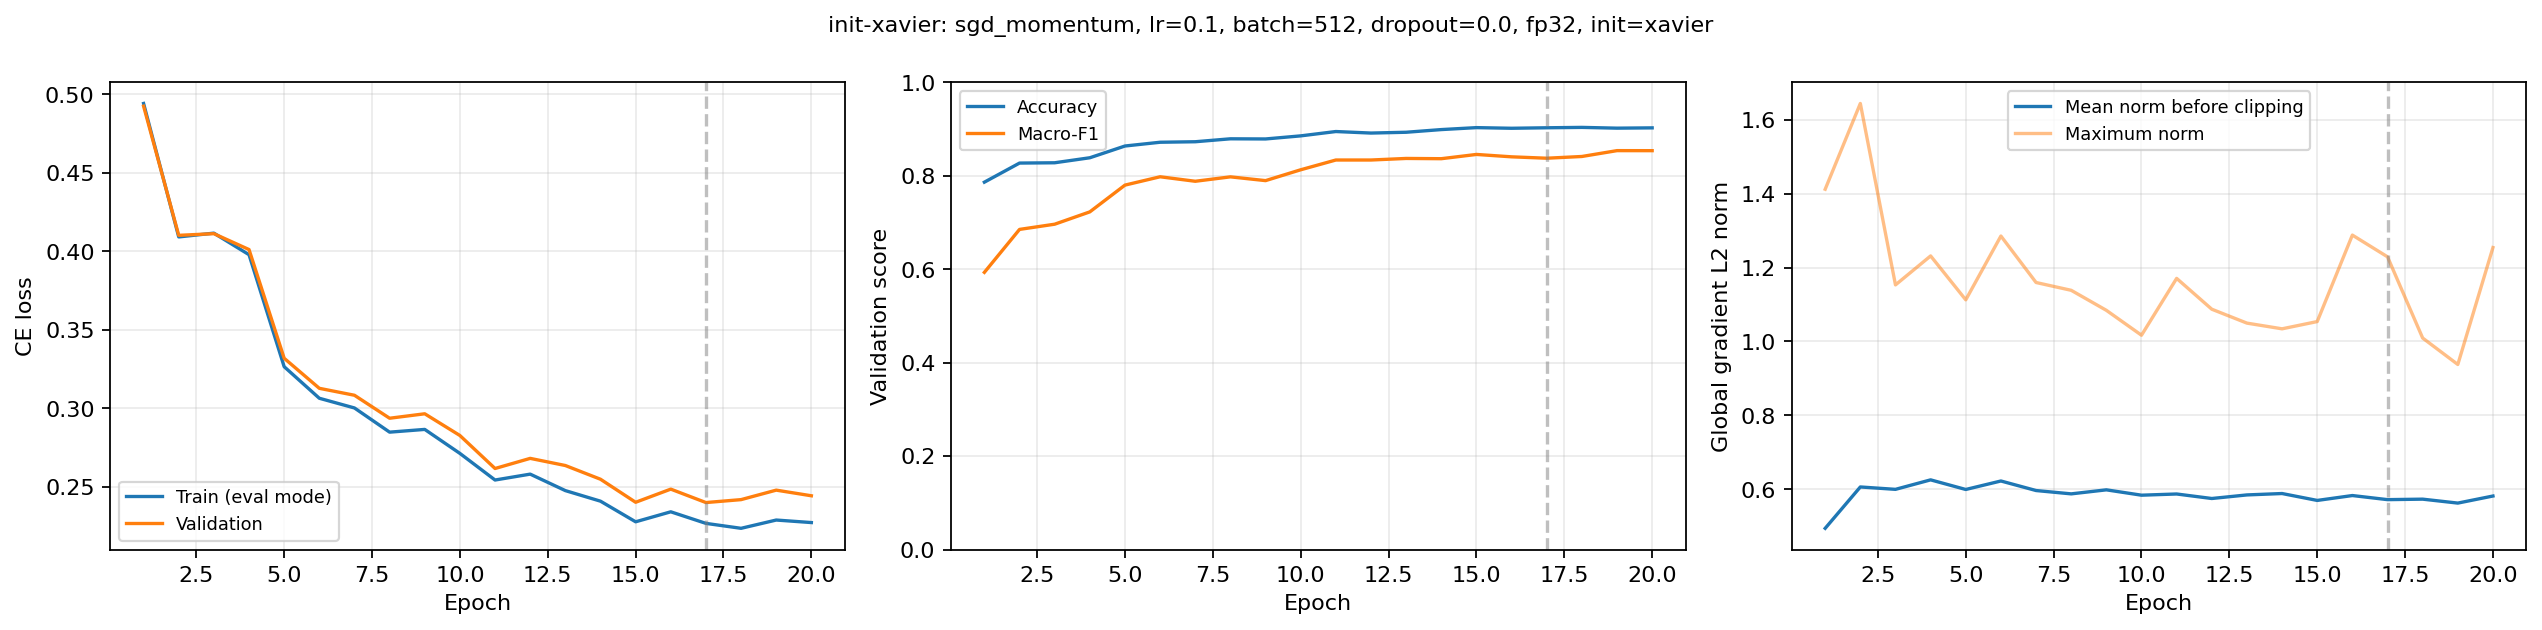

### init-zeros

Prediction: Xavier may change activation scale. Zero weights preserve symmetry and leave hidden ReLU gradients zero.

Prediction for init-zeros: Xavier may change activation scale. Zero weights preserve symmetry and leave hidden ReLU gradients zero.
init-zeros 01/20: train=1.2054 val=1.2054 acc=0.4876 F1=0.0936 time=1.23s
init-zeros 02/20: train=1.2053 val=1.2053 acc=0.4876 F1=0.0936 time=1.24s
init-zeros 03/20: train=1.2054 val=1.2054 acc=0.4876 F1=0.0936 time=1.24s
init-zeros 04/20: train=1.2053 val=1.2052 acc=0.4876 F1=0.0936 time=1.28s
init-zeros 05/20: train=1.2054 val=1.2053 acc=0.4876 F1=0.0936 time=1.25s
init-zeros 06/20: train=1.2052 val=1.2053 acc=0.4876 F1=0.0936 time=1.27s
init-zeros 07/20: train=1.2052 val=1.2052 acc=0.4876 F1=0.0936 time=1.24s
init-zeros 08/20: train=1.2056 val=1.2056 acc=0.4876 F1=0.0936 time=1.32s
init-zeros 09/20: train=1.2057 val=1.2057 acc=0.4876 F1=0.0936 time=1.45s
init-zeros 10/20: train=1.2052 val=1.2052 acc=0.4876 F1=0.0936 time=1.50s
init-zeros 11/20: train=1.2052 val=1.2052 acc=0.4876 F1=0.0936 time=1.39s
init-zeros 12/20: train=1.2053 val=1.2053 acc=0.4876 F

Observation: Best-checkpoint F1=0.093650, accuracy=0.487597, best epoch=10; F1 difference versus base-lr0p1-s1=-0.747339. Absolute difference exceeds the baseline 2-sigma reference (0.023788). Initial activation standard deviations=[0.0, 0.0, 0.0]. He uses variance 2/fan_in for ReLU; Xavier uses 2/(fan_in+fan_out). At zero initialization, ReLU derivatives block hidden-layer learning.

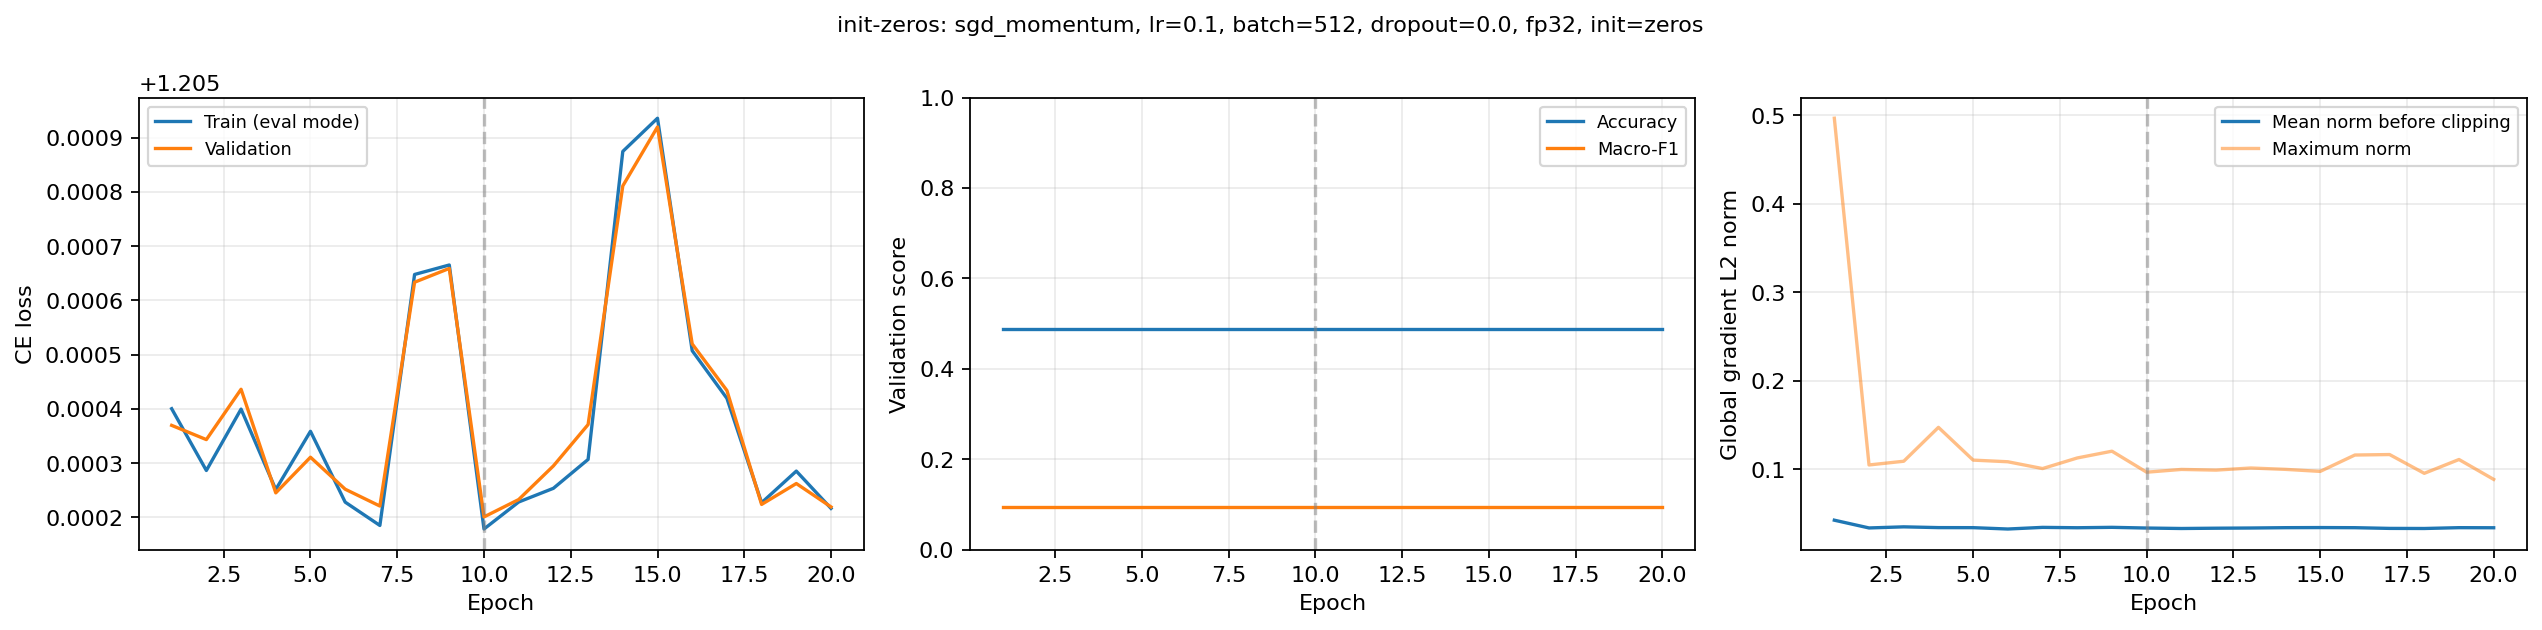

### amp-fp16

Prediction: FP16 should have similar F1 to FP32. Speed and memory gains may be small for this compact MLP.

Prediction for amp-fp16: FP16 should have similar F1 to FP32. Speed and memory gains may be small for this compact MLP.
amp-fp16 01/20: train=0.4694 val=0.4691 acc=0.7996 F1=0.6199 time=1.97s
amp-fp16 02/20: train=0.3972 val=0.3988 acc=0.8312 F1=0.7012 time=1.72s
amp-fp16 03/20: train=0.3824 val=0.3854 acc=0.8375 F1=0.7335 time=1.75s
amp-fp16 04/20: train=0.3771 val=0.3819 acc=0.8457 F1=0.7413 time=1.70s
amp-fp16 05/20: train=0.3152 val=0.3229 acc=0.8664 F1=0.7764 time=1.70s
amp-fp16 06/20: train=0.3022 val=0.3107 acc=0.8714 F1=0.7955 time=1.71s
amp-fp16 07/20: train=0.2904 val=0.3001 acc=0.8759 F1=0.7985 time=2.09s
amp-fp16 08/20: train=0.2821 val=0.2927 acc=0.8775 F1=0.7976 time=2.01s
amp-fp16 09/20: train=0.2738 val=0.2846 acc=0.8837 F1=0.8102 time=1.73s
amp-fp16 10/20: train=0.2737 val=0.2860 acc=0.8834 F1=0.8158 time=1.74s
amp-fp16 11/20: train=0.2626 val=0.2756 acc=0.8871 F1=0.8295 time=1.73s
amp-fp16 12/20: train=0.2492 val=0.2603 acc=0.8949 F1=0.8316 time=1.76s
amp-fp16 13/20: 

Observation: Best-checkpoint F1=0.845730, accuracy=0.905725, best epoch=18; F1 difference versus base-lr0p1-s1=+0.004740. Absolute difference does not exceed the baseline 2-sigma reference (0.023788). Epoch time ratio to FP32=1.363; peak allocated GPU MiB=200.37. FP16 has a narrow exponent range; GradScaler limits gradient underflow and skips overflow updates. BF16 has a wider range, but requires hardware support.

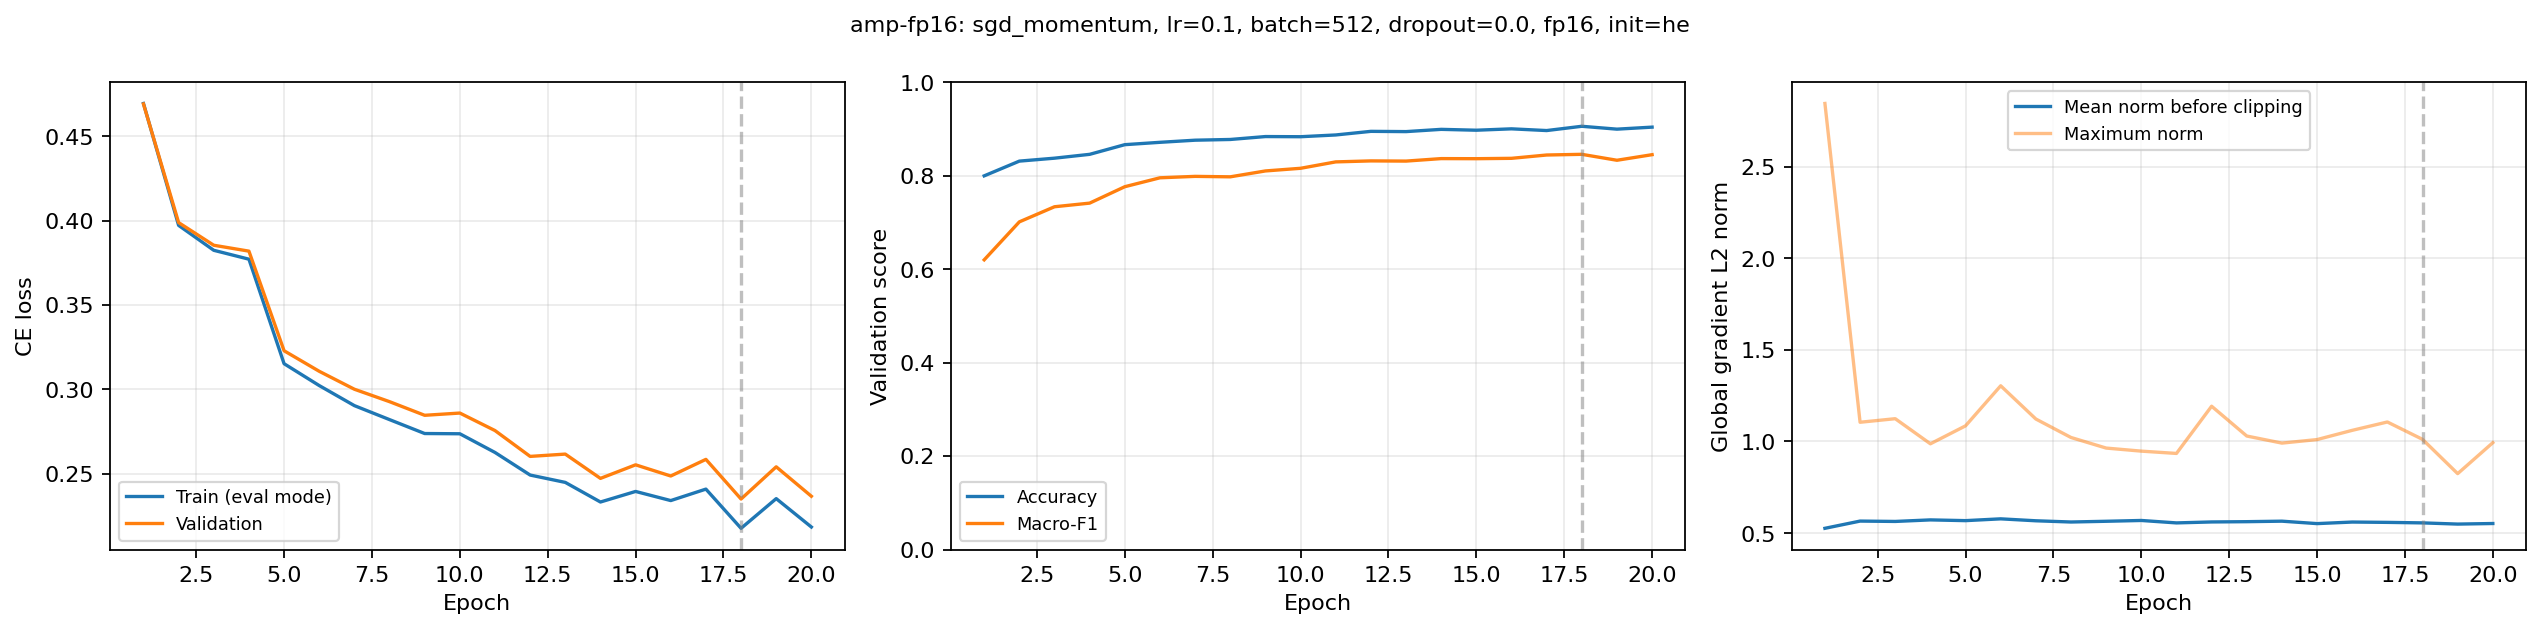

BF16 skipped: GPU support is unavailable. FP16 remains the precision comparison.


In [7]:
noise = seed_stats["val_macro_f1"]["noise_2sigma"]
for cfg in topic_trials(baseline, torch.device(device)):
    display(Markdown(f"### {cfg['exp_id']}\n\nPrediction: {PREDICTIONS[cfg['group']]}"))
    result = runner.run(cfg)
    reference = runner.results.get(cfg.get("reference"), baseline)
    if reference["summary"]["diverged"]:
        reference = baseline
    display(Markdown("Observation: " + observation(result, reference, noise)))
    display(Image(filename=str(OUT_DIR / "figures" / f"{cfg['exp_id']}.png")))
if not supports_bf16():
    print("BF16 skipped: GPU support is unavailable. FP16 remains the precision comparison.")
runner.comparisons(baseline)


## Part 4 - Final eval, workbook and report

Freeze the final configuration and seed before reading eval scores. Final ranking compares seed 1 configurations
by validation macro-F1 at their minimum-validation-loss checkpoints. The official evaluator scores only the designated
baseline and final configuration. No tuning follows evaluation. The generated report is a measured draft for your review.


Selected final configuration: batch-128
Report draft: /content/drive/MyDrive/NeuralNetworkLab/submission_2A202603012/REPORT.md
Open experiments.xlsx in Excel and save to refresh its formula caches.


,cls,support,precision,recall,f1
0,0,42368,0.905580,0.909790,0.907680
1,1,56661,0.924655,0.924851,0.924753
2,2,7151,0.901046,0.915536,0.908233
3,3,549,0.819188,0.808743,0.813932
4,4,1899,0.797446,0.723539,0.758697
5,5,3473,0.870801,0.776274,0.820825
6,6,4102,0.885431,0.936373,0.910190


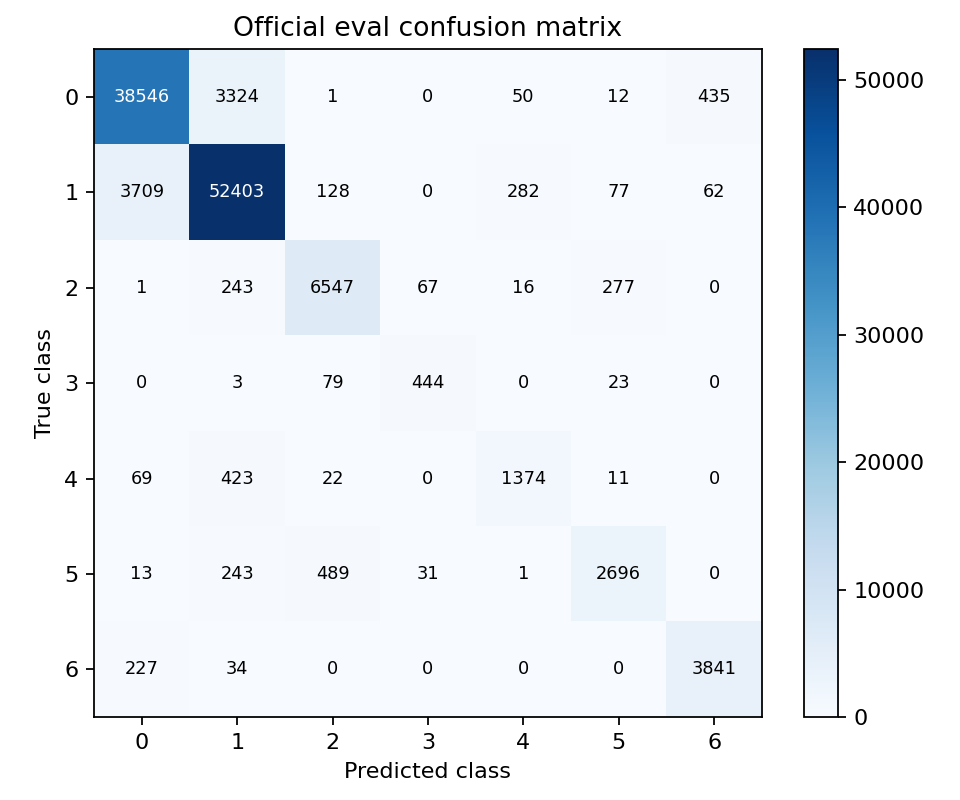

The lowest class F1 is class 4 (0.758697); it is most often confused with class 1. Imbalance and overlapping features are plausible explanations, which need feature analysis to verify. The report draft includes measured comparisons, noise limitations and the three initial checks for a stalled loss.

Results, figures, workbook, predictions and report draft: /content/drive/MyDrive/NeuralNetworkLab/submission_2A202603012
Training/evaluation cells completed. Save the executed notebook with outputs before packaging.


In [8]:
final_outputs = finalize(runner, baseline, baseline_seeds, seed_stats, diagnostics, STUDENT_ID)
final_scores = final_outputs["scores"][final_outputs["selection"]["final"]]
display(pd.DataFrame(final_scores["per_class"]))
display(Image(filename=str(OUT_DIR / "figures/eval_confusion.png")))
worst = min(final_scores["per_class"], key=lambda item: item["f1"])
cm = np.asarray(final_scores["confusion_matrix"])
errors = cm[worst["cls"]].copy()
errors[worst["cls"]] = 0
confusable = f"class {int(errors.argmax())}" if errors.max() else "no other class"
display(Markdown(
    f"The lowest class F1 is class {worst['cls']} ({worst['f1']:.6f}); it is most often confused with {confusable}. "
    "Imbalance and overlapping features are plausible explanations, which need feature analysis to verify. "
    "The report draft includes measured comparisons, noise limitations and the three initial checks for a stalled loss."
))
print("Results, figures, workbook, predictions and report draft:", OUT_DIR)
print("Training/evaluation cells completed. Save the executed notebook with outputs before packaging.")


### Save and package

Review `REPORT.md`, add your name and refine the explanations. If `REPORT.generated.md` exists, your previous report
was preserved; merge the draft into `REPORT.md`. Open `experiments.xlsx` in Excel and save to refresh formula caches.

After all cells complete, use **File > Download > Download .ipynb**. Follow the optional packaging snippet in
`code/RUNNING.md`: upload that executed notebook into the persistent `code/lab.ipynb`, then create and download the ZIP.
The notebook editor and the Python-visible file are different. Packaging refuses an unexecuted notebook.
Data, model weights and caches are excluded. No results in this notebook are invented or prefilled.
